In [1]:
import sys, tempfile, zipfile, os
sys.path.append('..') 

from scripts.constants import *
import ee, xee, geemap, eemont
import numpy as np
import xarray as xr
import rioxarray as rxr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import box
import xbatcher as xb
import xbatcher.loaders.torch
from dask.distributed import Client

In [2]:
# Trigger the authentication flow.
ee.Authenticate(force=True)
# Initialize the library.
ee.Initialize(project=GEE_PROJECT_NAME, opt_url='https://earthengine-highvolume.googleapis.com')
client = Client(n_workers=2, threads_per_worker=2, memory_limit='16GB')


Successfully saved authorization token.


/maps/acz25/miniconda3/envs/3-30-300-env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40281 instead
  warnings.warn(


In [3]:
efm_ic = ee.ImageCollection('projects/mldp-partners/assets/preview/efm_v2_preview')
start_date="2023-01-01"
end_date="2023-12-31"
filter_geometry = ee.FeatureCollection("FAO/GAUL/2015/level2") \
    .filter(ee.Filter.eq('ADM2_NAME', 'Greater London'))

# filter_geometry = ee.FeatureCollection("FAO/GAUL/2015/level2") \
#     .filter(ee.Filter.eq('ADM1_NAME', 'England'))

ifm_london_ic = (ee.ImageCollection(efm_ic) \
    .filterDate(start_date, end_date) \
    .filterBounds(filter_geometry.geometry()))

In [4]:
# Convert the Earth Engine FeatureCollection to a GeoPandas GeoDataFrame
filter_geometry_gdf = geemap.ee_to_gdf(filter_geometry)

# Get the total bounds of the filter geometry
total_bounds = filter_geometry_gdf.total_bounds

# Create a GeoDataFrame from the total bounds
bounds_gdf = gpd.GeoDataFrame(gpd.GeoSeries(box(*total_bounds)), columns=['geometry'], crs=filter_geometry_gdf.crs)

# Display the GeoDataFrame
bounds_gdf

AttributeError: 'NoneType' object has no attribute 'copy'

,geometry
0,"POLYGON ((0.33611 51.28249, 0.33611 51.68916, ..."


<Axes: >

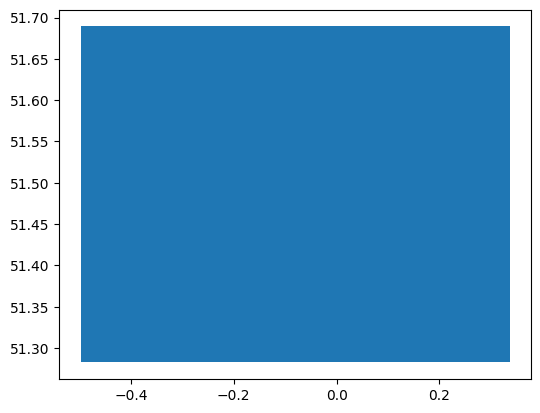

In [5]:
bounds_gdf.plot()

In [6]:
ifm_london_ds = xr.open_dataset(ifm_london_ic, engine='ee', scale=.05).rio.set_spatial_dims(y_dim='lat', x_dim='lon')#.rio.clip(bounds_gdf.geometry.values)
ifm_london_ds

<xarray.Dataset> Size: 13GB
Dimensions:  (time: 2, lon: 7200, lat: 3600)
Coordinates:
  * time     (time) datetime64[ns] 16B 2023-01-01 2023-01-01
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * lat      (lat) float64 29kB -89.97 -89.92 -89.88 ... 89.88 89.93 89.98
Data variables: (12/64)
    A00      (time, lon, lat) float32 207MB ...
    A01      (time, lon, lat) float32 207MB ...
    A02      (time, lon, lat) float32 207MB ...
    A03      (time, lon, lat) float32 207MB ...
    A04      (time, lon, lat) float32 207MB ...
    A05      (time, lon, lat) float32 207MB ...
    ...       ...
    A58      (time, lon, lat) float32 207MB ...
    A59      (time, lon, lat) float32 207MB ...
    A60      (time, lon, lat) float32 207MB ...
    A61      (time, lon, lat) float32 207MB ...
    A62      (time, lon, lat) float32 207MB ...
    A63      (time, lon, lat) float32 207MB ...
Attributes:
    crs:      EPSG:4326

In [7]:
x = ifm_london_ds.rio.clip(bounds_gdf.geometry.values)

In [12]:
x

<xarray.Dataset> Size: 70kB
Dimensions:      (time: 2, lon: 17, lat: 8)
Coordinates:
  * time         (time) datetime64[ns] 16B 2023-01-01 2023-01-01
  * lon          (lon) float64 136B -0.475 -0.425 -0.375 ... 0.225 0.275 0.325
  * lat          (lat) float64 64B 51.33 51.38 51.43 51.48 ... 51.58 51.63 51.68
    spatial_ref  int64 8B 0
Data variables: (12/64)
    A00          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A01          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A02          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A03          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A04          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A05          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    ...           ...
    A58          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A59          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A60          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A61          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A62          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
    A63          (time, lon, lat) float32 1kB nan nan nan nan ... nan nan nan
Attributes:
    crs:      EPSG:4326

In [71]:
ifm_london_first_time_point_bands

<xarray.DataArray (band: 64, lon: 360, lat: 180)> Size: 17MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2023-01-01
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * band     (band) object 512B 'A00' 'A01' 'A02' 'A03' ... 'A61' 'A62' 'A63'
Attributes:
    crs:      EPSG:4326

In [49]:
ifm_london_ds_first_time_point = ifm_london_ds.isel(time=0)
ifm_london_ds_first_time_point
ifm_london_first_time_point_bands = ifm_london_ds_first_time_point.to_array(dim='band')
ifm_london_first_time_point_bands

<xarray.DataArray (band: 64, lon: 360, lat: 180)> Size: 17MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2023-01-01
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * band     (band) object 512B 'A00' 'A01' 'A02' 'A03' ... 'A61' 'A62' 'A63'
Attributes:
    crs:      EPSG:4326

In [56]:
ifm_london_first_time_point_bands.rio.set_spatial_dims(y_dim='lat', x_dim='lon').rio.bounds()

(-180.0, -90.0, 180.0, 90.0)

In [34]:
# Transform variables to bands of a DataArray
ifm_london_bands = ifm_london_ds.to_array(dim='band')
ifm_london_bands

<xarray.DataArray (band: 64, time: 2, lon: 360, lat: 180)> Size: 33MB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]],


       [[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
...
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]],


       [[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 16B 2023-01-01 2023-01-01
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * band     (band) object 512B 'A00' 'A01' 'A02' 'A03' ... 'A61' 'A62' 'A63'
Attributes:
    crs:      EPSG:4326

In [35]:
pixel_values

<xarray.Dataset> Size: 544B
Dimensions:  (time: 2)
Coordinates:
  * time     (time) datetime64[ns] 16B 2023-01-01 2023-01-01
    lon      float64 8B -0.5
    lat      float64 8B 51.5
Data variables: (12/64)
    A00      (time) float32 8B 0.05912 0.04823
    A01      (time) float32 8B -0.03845 -0.05173
    A02      (time) float32 8B 0.1191 0.1137
    A03      (time) float32 8B 0.06299 0.07111
    A04      (time) float32 8B -0.01575 -0.01206
    A05      (time) float32 8B -0.07111 -0.07536
    ...       ...
    A58      (time) float32 8B 0.08421 0.08883
    A59      (time) float32 8B -0.05173 -0.04484
    A60      (time) float32 8B 0.07536 0.06699
    A61      (time) float32 8B -0.03254 -0.01778
    A62      (time) float32 8B 0.03543 0.01993
    A63      (time) float32 8B -0.1794 -0.1794
Attributes:
    crs:      EPSG:4326

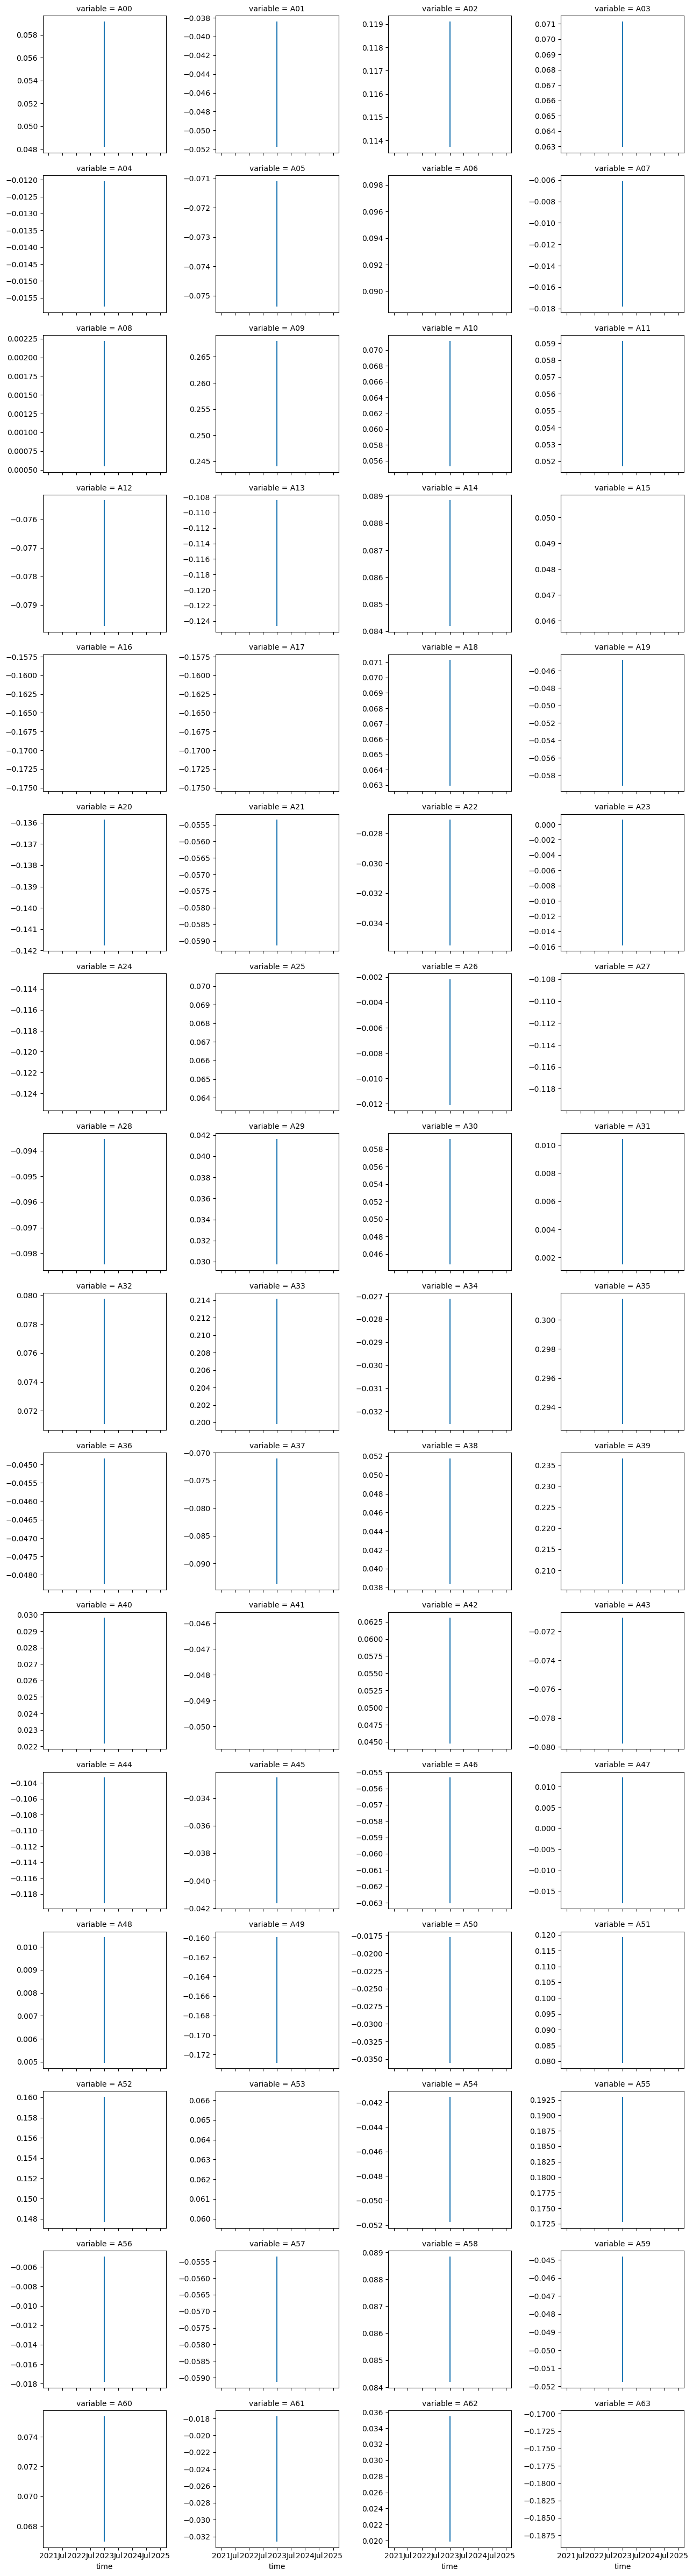

In [32]:
# Define the latitude and longitude of the pixel you want to compare
lat = 51.5074  # Example latitude for London
lon = -0.1278  # Example longitude for London

# Select the pixel values for all time steps
pixel_values = ifm_london_ds.sel(lat=lat, lon=lon, method='nearest')

# Plot the pixel values over time for each variable
pixel_values.to_array().plot.line(x='time', col='variable', col_wrap=4, sharey=False)
plt.show()

(64, 2, 360, 180)

In [6]:
import torch

# Convert the xarray dataset to a numpy array
ifm_london_np = ifm_london_ds.to_array().values

# Convert the numpy array to a tensor
ifm_london_tensor = torch.tensor(ifm_london_np)

ifm_london_tensor

tensor([[[[nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          ...,
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan]],

         [[nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          ...,
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan]]],


        [[[nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          ...,
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan]],

         [[nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan

In [5]:
ifm_london_ds.dims

FrozenMappingWarningOnValuesAccess({'time': 2, 'lon': 360, 'lat': 180})

In [62]:
ifm_london_ds['A01'].transpose('time', 'lat', 'lon').rio.set_spatial_dims(y_dim='lat', x_dim='lon').rio.to_raster('ifm_london_A01.tif')

In [74]:
# Create a map centered at London
Map = geemap.Map(center=[51.5074, -0.1278], zoom=10)

# Convert xarray dataset to an ee.Image
# ifm_london_image = geemap.xarray_to_ee(ifm_london_ds, band_names=list(ifm_london_ds.data_vars))

# Add the image to the map
Map.addLayer(ifm_london_ic, {}, 'IFM London')

# Display the map
Map

Map(center=[51.5074, -0.1278], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDa…